# Bank Customer Transaction Behavior & Customer Value Analysis
## 銀行客戶交易行為與客戶價值分析

本專案使用銀行客戶交易資料，透過 Python 與 Pandas 進行資料清理、探索性資料分析（EDA）及客戶行為分析，從時間、年齡、性別與交易頻率等面向觀察客戶交易特徵，並進一步比較單次交易與重複交易客戶的交易價值。

分析目的為從交易資料中識別重要的客戶行為特徵，並將分析結果轉化為可供客群經營與業務決策參考的洞察。

## Analysis Objectives

本專案主要回答以下問題：

1. 銀行整體交易金額與交易筆數呈現什麼特徵？
2. 不同日期與星期的交易活動是否存在明顯差異？
3. 不同年齡與性別客群的交易行為有何差異？
4. 單次交易與重複交易客戶的交易價值是否有所不同？
5. 根據上述分析，可以提出哪些客群經營與業務應用方向？

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## 1. Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../data/bank_transactions.csv")

In [3]:
df.shape

(1048567, 9)

In [4]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB


In [6]:
df.isnull().sum()

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

TransactionID              1048567
CustomerID                  884265
CustomerDOB                  17254
CustGender                       3
CustLocation                  9355
CustAccountBalance          161328
TransactionDate                 55
TransactionTime              81918
TransactionAmount (INR)      93024
dtype: int64

In [9]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [10]:
df[["CustomerDOB", "CustGender", "CustLocation"]].isnull().any(axis=1).sum()

np.int64(4585)

## 2. Data Cleaning

In [11]:
df = df.dropna(subset=["CustomerDOB", "CustGender", "CustLocation"])

In [12]:
df.shape[0]

1043982

In [13]:
df[["CustomerDOB", "CustGender", "CustLocation"]].isnull().sum()

CustomerDOB     0
CustGender      0
CustLocation    0
dtype: int64

In [14]:
df["CustAccountBalance"].isnull().sum()

np.int64(2368)

In [15]:
df = df.dropna(subset=["CustAccountBalance"])

In [16]:
df.shape[0]

1041614

In [17]:
df[["CustAccountBalance"]].isnull().sum()

CustAccountBalance    0
dtype: int64

In [18]:
df["CustomerDOB"].str.len().value_counts()

CustomerDOB
7    569826
6    250015
8    221773
Name: count, dtype: int64

In [19]:
df["CustomerDOB"].head(20)

0      10/1/94
1       4/4/57
2     26/11/96
3      14/9/73
4      24/3/88
5      8/10/72
6      26/1/92
7      27/1/82
8      19/4/88
9      22/6/84
10     22/7/82
11      7/7/88
12     13/6/78
13      5/1/92
14     24/3/78
15     10/7/68
16    1/1/1800
17     16/7/89
18     11/1/91
19     24/6/85
Name: CustomerDOB, dtype: str

In [20]:
df["CustomerDOB"].str.contains("1800").sum()

np.int64(56292)

In [21]:
df["CustomerDOB"].str.split("/").str[-1].value_counts().sort_index()

CustomerDOB
00      269
01      142
02       98
03       69
04       75
      ...  
95    20704
96    12480
97     7155
98     1936
99      688
Name: count, Length: 100, dtype: int64

In [22]:
df.loc[
    df["CustomerDOB"].str.contains("1800"),
    "CustomerDOB"
].value_counts()

CustomerDOB
1/1/1800    56292
Name: count, dtype: int64

In [23]:
df["CustomerDOB"] = df["CustomerDOB"].replace("1/1/1800", pd.NA)

In [24]:
df["CustomerDOB"].isnull().sum()

np.int64(56292)

In [25]:
df["TransactionDate"].head(20)

0     2/8/16
1     2/8/16
2     2/8/16
3     2/8/16
4     2/8/16
5     2/8/16
6     2/8/16
7     2/8/16
8     2/8/16
9     2/8/16
10    2/8/16
11    2/8/16
12    2/8/16
13    1/8/16
14    1/8/16
15    1/8/16
16    1/8/16
17    1/8/16
18    1/8/16
19    1/8/16
Name: TransactionDate, dtype: str

In [26]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    format="%d/%m/%y"
)

In [27]:
df["TransactionDate"].head()

0   2016-08-02
1   2016-08-02
2   2016-08-02
3   2016-08-02
4   2016-08-02
Name: TransactionDate, dtype: datetime64[us]

In [28]:
df["TransactionDate"].min()

Timestamp('2016-08-01 00:00:00')

In [29]:
df["TransactionDate"].max()

Timestamp('2016-10-21 00:00:00')

In [30]:
dob_year = df["CustomerDOB"].str.split("/").str[-1]

In [31]:
dob_year.value_counts().sort_index().head(25)

CustomerDOB
00    269
01    142
02     98
03     69
04     75
05     30
06     21
07     46
08     16
09     17
10     14
11      2
12     28
13     27
14     10
15     25
16      2
18      1
19      7
20      2
21     22
22      3
23      6
24      3
25      1
Name: count, dtype: int64

In [32]:
df["CustomerDOB_parsed"] = pd.to_datetime(
    df["CustomerDOB"],
    format="%d/%m/%y",
    errors="coerce"
)

In [33]:
df[["CustomerDOB", "CustomerDOB_parsed"]].head(20)

,CustomerDOB,CustomerDOB_parsed
0,10/1/94,1994-01-10
1,4/4/57,2057-04-04
2,26/11/96,1996-11-26
3,14/9/73,1973-09-14
4,24/3/88,1988-03-24
5,8/10/72,1972-10-08
6,26/1/92,1992-01-26
7,27/1/82,1982-01-27
8,19/4/88,1988-04-19
9,22/6/84,1984-06-22


In [34]:
df["CustomerDOB_parsed"].dt.year.value_counts().sort_index()

CustomerDOB_parsed
1969.0    5951
1970.0    7281
1971.0    7371
1972.0    9215
1973.0    9908
          ... 
2064.0    3571
2065.0    3885
2066.0    4197
2067.0    4452
2068.0    5894
Name: count, Length: 99, dtype: int64

In [35]:
birth_year = pd.to_numeric(dob_year)

In [36]:
birth_year = birth_year + 1900

In [37]:
birth_year.head(20)

0     1994.0
1     1957.0
2     1996.0
3     1973.0
4     1988.0
5     1972.0
6     1992.0
7     1982.0
8     1988.0
9     1984.0
10    1982.0
11    1988.0
12    1978.0
13    1992.0
14    1978.0
15    1968.0
16       NaN
17    1989.0
18    1991.0
19    1985.0
Name: CustomerDOB, dtype: float64

In [38]:
age_approx = df["TransactionDate"].dt.year - birth_year

In [39]:
age_approx.describe()

count    985322.000000
mean         31.119964
std           9.075800
min          17.000000
25%          25.000000
50%          29.000000
75%          34.000000
max         116.000000
dtype: float64

In [40]:
age_approx.value_counts().sort_index()

17.0       688
18.0      1936
19.0      7155
20.0     12480
21.0     20704
         ...  
112.0       75
113.0       69
114.0       98
115.0      142
116.0      269
Name: count, Length: 99, dtype: int64

In [41]:
age_approx[age_approx >= 60].value_counts().sort_index()

60.0     1553
61.0     1761
62.0     1800
63.0     1499
64.0     1477
65.0     1037
66.0      973
67.0      778
68.0      726
69.0      708
70.0      463
71.0      394
72.0      412
73.0      302
74.0      400
75.0      290
76.0      293
77.0      183
78.0      244
79.0      164
80.0      101
81.0       97
82.0       67
83.0       73
84.0       79
85.0       73
86.0       63
87.0       63
88.0       22
89.0       49
90.0       10
91.0        1
92.0        3
93.0        6
94.0        3
95.0       22
96.0        2
97.0        7
98.0        1
100.0       2
101.0      25
102.0      10
103.0      27
104.0      28
105.0       2
106.0      14
107.0      17
108.0      16
109.0      46
110.0      21
111.0      30
112.0      75
113.0      69
114.0      98
115.0     142
116.0     269
Name: count, dtype: int64

In [42]:
age_approx[age_approx >= 85].value_counts().sort_index()

85.0      73
86.0      63
87.0      63
88.0      22
89.0      49
90.0      10
91.0       1
92.0       3
93.0       6
94.0       3
95.0      22
96.0       2
97.0       7
98.0       1
100.0      2
101.0     25
102.0     10
103.0     27
104.0     28
105.0      2
106.0     14
107.0     17
108.0     16
109.0     46
110.0     21
111.0     30
112.0     75
113.0     69
114.0     98
115.0    142
116.0    269
Name: count, dtype: int64

In [43]:
(age_approx >= 100).sum()

np.int64(891)

In [44]:
(age_approx >= 100).mean()

np.float64(0.000855403249188279)

In [45]:
df.groupby('CustomerID')['CustomerDOB'].nunique().value_counts()

CustomerDOB
1    711065
2    112539
0     40277
3     14060
4      1310
5       102
6         5
Name: count, dtype: int64

In [46]:
df.groupby('CustomerID')['CustGender'].nunique().value_counts()

CustGender
1    820017
2     59341
Name: count, dtype: int64

In [47]:
df.groupby('CustomerID')['CustLocation'].nunique().value_counts()

CustLocation
1    742909
2    120163
3     14819
4      1363
5        95
6         9
Name: count, dtype: int64

In [48]:
df["Age"] = df["TransactionDate"].dt.year - birth_year

In [49]:
df.loc[df["Age"]>=100, "Age"] = pd.NA

In [50]:
df["Age"].describe()

count    984431.000000
mean         31.046309
std           8.742378
min          17.000000
25%          25.000000
50%          29.000000
75%          34.000000
max          98.000000
Name: Age, dtype: float64

In [51]:
df["Age"].isnull().sum()

np.int64(57183)

In [52]:
df.shape[0]

1041614

In [53]:
df["AgeGroup"] = pd.cut( df["Age"], bins=[17, 25, 35, 45, 55, 65, float("inf")], labels=['17-24', '25-34', '35-44', '45-54', '55-64', '65+'], right=False )

In [54]:
df["AgeGroup"].value_counts().sort_index()

AgeGroup
17-24    198768
25-34    542631
35-44    168273
45-54     48837
55-64     17813
65+        8109
Name: count, dtype: int64

In [55]:
df["CustGender"].value_counts(dropna=False)

CustGender
M    760978
F    280635
T         1
Name: count, dtype: int64

In [56]:
df.loc[df["CustGender"] == 'T', "CustGender"] = pd.NA

In [57]:
df["CustGender"].value_counts(dropna=False)

CustGender
M      760978
F      280635
NaN         1
Name: count, dtype: int64

In [58]:
df["CustLocation"].value_counts().head(20)

CustLocation
MUMBAI         101997
NEW DELHI       84143
BANGALORE       81330
GURGAON         73594
DELHI           70549
NOIDA           32656
CHENNAI         29840
PUNE            25690
HYDERABAD       22976
THANE           21397
KOLKATA         19851
GHAZIABAD       15722
NAVI MUMBAI     12916
AHMEDABAD       12145
FARIDABAD       11226
JAIPUR           9830
CHANDIGARH       9500
LUCKNOW          7750
MOHALI           6656
SURAT            5704
Name: count, dtype: int64

In [59]:
df["CustLocation"].str.strip().nunique()

9274

In [60]:
df["CustLocation"] = df["CustLocation"].str.strip()

In [61]:
df["CustLocation"].nunique()

9274

In [62]:
df["CustAccountBalance"].quantile([0.9, 0.95, 0.99, 0.995, 0.999])

0.900     197787.005
0.950     414522.230
0.990    1586508.610
0.995    2573182.560
0.999    6994347.730
Name: CustAccountBalance, dtype: float64

In [67]:
(df["CustAccountBalance"] == 0).sum()

np.int64(2612)

In [68]:
(df["CustAccountBalance"] == 0).mean()

np.float64(0.0025076467866215315)

In [69]:
df["TransactionAmount (INR)"].describe()

count    1.041614e+06
mean     1.566096e+03
std      6.561464e+03
min      0.000000e+00
25%      1.600000e+02
50%      4.575000e+02
75%      1.200000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64

In [70]:
df["TransactionAmount (INR)"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900     2925.0
0.950     5176.0
0.990    20000.0
0.995    31000.0
0.999    95000.0
Name: TransactionAmount (INR), dtype: float64

In [71]:
(df["TransactionAmount (INR)"] == 0).agg(["sum", "mean"])

sum     820.000000
mean      0.000787
Name: TransactionAmount (INR), dtype: float64

In [72]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)', 'CustomerDOB_parsed',
       'Age', 'AgeGroup'],
      dtype='str')

In [73]:
df.shape[0]

1041614

In [74]:
df['TransactionAmount (INR)'].sum()

np.float64(1631267601.72)

In [75]:
df['TransactionAmount (INR)'].mean()

np.float64(1566.096079468978)

In [76]:
df['TransactionAmount (INR)'].median()

np.float64(457.5)

## 3. Exploratory Data Analysis
### 3.1 Overall Transaction Analysis

In [80]:
daily_summary = df.groupby("TransactionDate").agg(
    TransactionCount=("TransactionID", "count"),
    TotalAmount=("TransactionAmount (INR)", "sum"),
    AverageAmount=("TransactionAmount (INR)", "mean")
)

In [81]:
daily_summary.head()

,TransactionCount,TotalAmount,AverageAmount
TransactionDate,,,
2016-08-01,20277,29328167.34,1446.376059
2016-08-02,20787,30165998.15,1451.195370
2016-08-03,20446,30655826.28,1499.355682
2016-08-04,20535,35352319.56,1721.564137
2016-08-05,20949,34431417.46,1643.582866


In [82]:
daily_summary.describe()

,TransactionCount,TotalAmount,AverageAmount
count,55.000000,5.500000e+01,55.000000
mean,18938.436364,2.965941e+07,1545.900968
std,6352.690689,1.058512e+07,210.250753
min,3.000000,1.067000e+03,355.666667
25%,18158.500000,2.737567e+07,1465.069271
50%,20611.000000,3.016600e+07,1535.637012
75%,21673.500000,3.407508e+07,1636.153762
max,27084.000000,4.720295e+07,2093.803645


In [83]:
daily_summary.shape[0]

55

In [84]:
daily_summary[
    daily_summary["TransactionCount"] == (daily_summary["TransactionCount"].min())
]

,TransactionCount,TotalAmount,AverageAmount
TransactionDate,,,
2016-10-16,3,1067.0,355.666667


In [85]:
daily_summary.sort_values(
    by="TransactionCount",
    ascending=True
).head(10)

,TransactionCount,TotalAmount,AverageAmount
TransactionDate,,,
2016-10-16,3,1067.00,355.666667
2016-09-30,1935,3273193.81,1691.573028
2016-09-23,3460,4682132.64,1353.217526
2016-10-21,3641,7623539.07,2093.803645
2016-09-22,6925,12590042.45,1818.056671
2016-09-27,7401,10785749.73,1457.336810
2016-09-25,8127,11926258.80,1467.486010
2016-09-26,12376,20477176.09,1654.587596
2016-09-18,14622,23537230.39,1609.713472


### 3.2 Time Analysis
為避免原始資料後段日期缺漏影響趨勢判讀，本分析使用日期連續完整的 2016-08-01 至 2016-09-15 作為時間趨勢分析期間。

本節主要觀察每日交易量變化，以及不同星期的交易活動是否存在差異。

In [86]:
full_dates = pd.date_range(
    start=df["TransactionDate"].min(),
    end=df["TransactionDate"].max(),
    freq="D"
)

In [87]:
full_dates[ ~full_dates.isin(daily_summary.index)]

DatetimeIndex(['2016-09-16', '2016-09-17', '2016-09-19', '2016-09-20',
               '2016-09-21', '2016-09-24', '2016-09-28', '2016-09-29',
               '2016-10-01', '2016-10-02', '2016-10-03', '2016-10-04',
               '2016-10-05', '2016-10-06', '2016-10-07', '2016-10-08',
               '2016-10-09', '2016-10-10', '2016-10-11', '2016-10-12',
               '2016-10-13', '2016-10-14', '2016-10-15', '2016-10-17',
               '2016-10-18', '2016-10-19', '2016-10-20'],
              dtype='datetime64[us]', freq=None)

In [88]:
complete_period = pd.date_range(
    start="2016-08-01",
    end="2016-09-15",
    freq="D"
)

In [89]:
complete_period[
    ~complete_period.isin(daily_summary.index)
]

DatetimeIndex([], dtype='datetime64[us]', freq='D')

In [90]:
trend_df = df[
    (df["TransactionDate"] >= "2016-08-01") &
    (df["TransactionDate"] <= "2016-09-15")
].copy()

In [91]:
daily_trend = trend_df.groupby("TransactionDate").agg(
    TransactionCount=("TransactionID", "count"),
    TotalAmount=("TransactionAmount (INR)", "sum"),
    AverageAmount=("TransactionAmount (INR)", "mean")
)

In [92]:
daily_trend.shape

(46, 3)

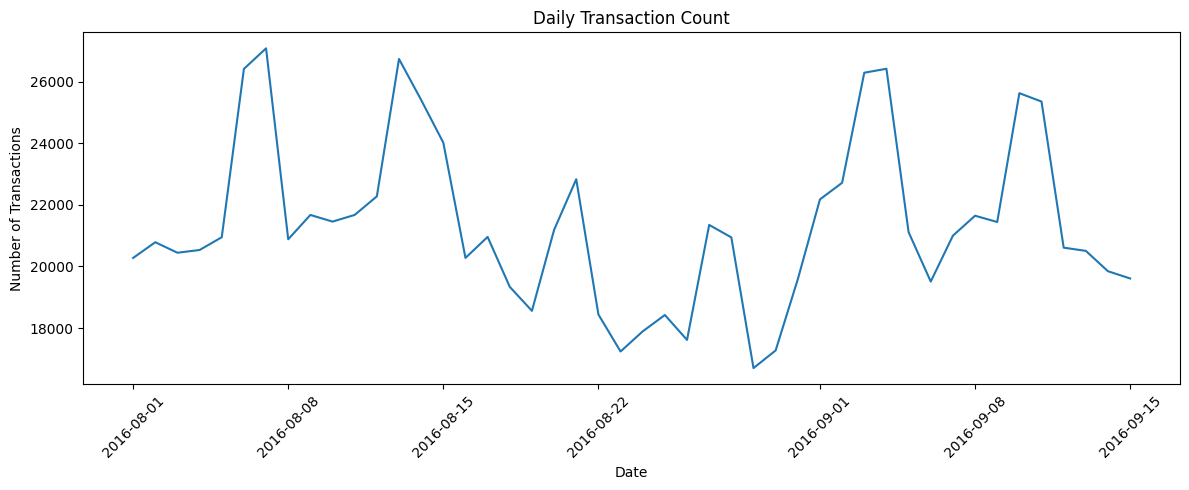

In [93]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_trend.index,
    daily_trend["TransactionCount"]
)

plt.title("Daily Transaction Count")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [94]:
trend_df["DayOfWeek"] = trend_df["TransactionDate"].dt.day_name()

In [95]:
trend_df[["TransactionDate", "DayOfWeek"]].head()

,TransactionDate,DayOfWeek
0,2016-08-02,Tuesday
1,2016-08-02,Tuesday
2,2016-08-02,Tuesday
3,2016-08-02,Tuesday
4,2016-08-02,Tuesday


In [96]:
daily_trend["DayOfWeek"] = daily_trend.index.day_name()

In [97]:
daily_trend.groupby("DayOfWeek")["TransactionCount"].mean()

DayOfWeek
Friday       20593.666667
Monday       20292.571429
Saturday     24601.833333
Sunday       24673.833333
Thursday     20486.857143
Tuesday      19609.428571
Wednesday    20169.428571
Name: TransactionCount, dtype: float64

In [98]:
weekday_avg = daily_trend[
    daily_trend["DayOfWeek"].isin(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
    )
]["TransactionCount"].mean()

weekend_avg = daily_trend[
    daily_trend["DayOfWeek"].isin(["Saturday", "Sunday"])
]["TransactionCount"].mean()

weekend_increase = (weekend_avg / weekday_avg - 1) * 100

weekday_avg, weekend_avg, weekend_increase

(np.float64(20219.70588235294),
 np.float64(24637.833333333332),
 np.float64(21.850601965661532))

In [99]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_avg = (
    daily_trend.groupby("DayOfWeek")["TransactionCount"]
    .mean()
    .reindex(day_order)
)

In [100]:
day_avg

DayOfWeek
Monday       20292.571429
Tuesday      19609.428571
Wednesday    20169.428571
Thursday     20486.857143
Friday       20593.666667
Saturday     24601.833333
Sunday       24673.833333
Name: TransactionCount, dtype: float64

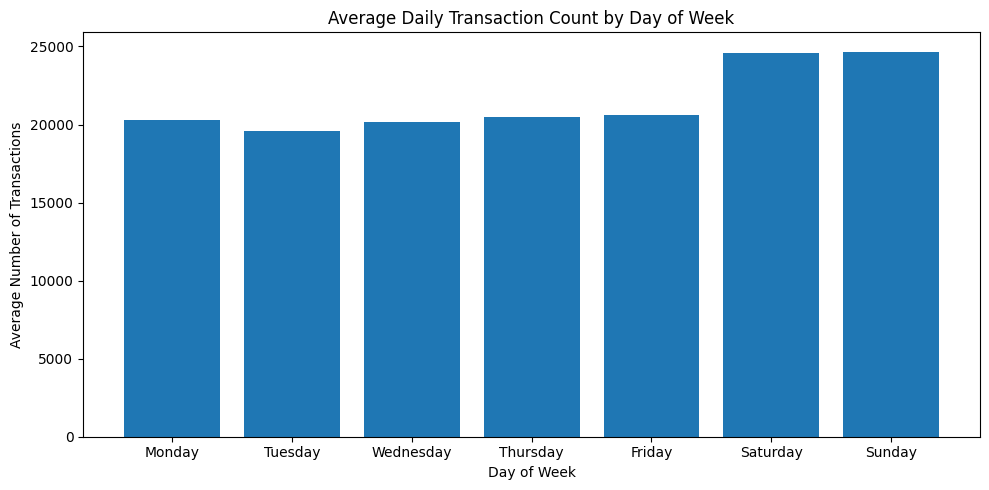

In [101]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_avg.index,
    day_avg.values
)

plt.title("Average Daily Transaction Count by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Transactions")

plt.tight_layout()
plt.show()

In [102]:
daily_trend.columns

Index(['TransactionCount', 'TotalAmount', 'AverageAmount', 'DayOfWeek'], dtype='str')

In [103]:
day_total_amount = (
    daily_trend.groupby("DayOfWeek")["TotalAmount"]
    .mean()
    .reindex(day_order)
)

In [104]:
day_average_amount = (
    daily_trend.groupby("DayOfWeek")["AverageAmount"]
    .mean()
    .reindex(day_order)
)

In [105]:
day_total_amount

DayOfWeek
Monday       3.133873e+07
Tuesday      2.948384e+07
Wednesday    3.041864e+07
Thursday     3.149104e+07
Friday       3.176048e+07
Saturday     4.071444e+07
Sunday       4.039933e+07
Name: TotalAmount, dtype: float64

In [106]:
day_average_amount

DayOfWeek
Monday       1534.578822
Tuesday      1503.833662
Wednesday    1510.458873
Thursday     1538.357709
Friday       1537.165267
Saturday     1651.478735
Sunday       1630.107391
Name: AverageAmount, dtype: float64

In [108]:
weekday_amount_avg = day_average_amount.loc[
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
].mean()

In [109]:
weekend_amount_avg = day_average_amount.loc[
    ["Saturday", "Sunday"]
].mean()

In [110]:
amount_increase = (
    weekend_amount_avg / weekday_amount_avg - 1
) * 100

In [111]:
weekday_amount_avg, weekend_amount_avg, amount_increase

(np.float64(1524.878866698436),
 np.float64(1640.7930632904058),
 np.float64(7.601534726685499))

In [112]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)', 'CustomerDOB_parsed',
       'Age', 'AgeGroup'],
      dtype='str')

### 3.3 Customer Analysis
本節從年齡與性別分析不同客群的交易行為。除比較交易筆數外，同時使用每客戶平均交易次數、平均交易金額及中位交易金額，避免僅因客群人數差異或極端交易金額而產生誤判。

In [113]:
age_summary = df.groupby("AgeGroup", observed=True).agg(
    TransactionCount=("TransactionID", "count"),
    AverageAmount=("TransactionAmount (INR)", "mean"),
    MedianAmount=("TransactionAmount (INR)", "median")
)

In [114]:
age_summary

,TransactionCount,AverageAmount,MedianAmount
AgeGroup,,,
17-24,198768,823.932600,227.0
25-34,542631,1270.061961,400.0
35-44,168273,2073.570966,700.0
45-54,48837,2852.082769,920.0
55-64,17813,3305.099269,1000.0
65+,8109,3632.036878,999.0


In [115]:
age_summary = df.groupby("AgeGroup", observed=True).agg(
    CustomerCount=("CustomerID", "nunique"),
    TransactionCount=("TransactionID", "count"),
    AverageAmount=("TransactionAmount (INR)", "mean"),
    MedianAmount=("TransactionAmount (INR)", "median")
)

In [116]:
age_summary["TransactionsPerCustomer"] = age_summary["TransactionCount"] / age_summary["CustomerCount"]

In [117]:
age_summary

,CustomerCount,TransactionCount,AverageAmount,MedianAmount,TransactionsPerCustomer
AgeGroup,,,,,
17-24,192114,198768,823.932600,227.0,1.034636
25-34,495549,542631,1270.061961,400.0,1.095010
35-44,163328,168273,2073.570966,700.0,1.030276
45-54,48339,48837,2852.082769,920.0,1.010302
55-64,17744,17813,3305.099269,1000.0,1.003889
65+,8090,8109,3632.036878,999.0,1.002349


In [118]:
gender_summary = df.groupby("CustGender", observed=True).agg(
    CustomerCount=("CustomerID", "nunique"),
    TransactionCount=("TransactionID", "count"),
    AverageAmount=("TransactionAmount (INR)", "mean"),
    MedianAmount=("TransactionAmount (INR)", "median")
)

In [119]:
gender_summary["TransactionsPerCustomer"] = gender_summary["TransactionCount"] / gender_summary["CustomerCount"]

In [120]:
gender_summary

,CustomerCount,TransactionCount,AverageAmount,MedianAmount,TransactionsPerCustomer
CustGender,,,,,
F,267486,280635,1643.958457,518.0,1.049158
M,671212,760978,1537.341185,420.0,1.133737


### 3.4 Customer Value Analysis
將交易資料彙總至客戶層級後，分析客戶交易次數與交易金額。由於大部分客戶在觀察期間內僅出現一次交易，因此本節不直接套用傳統 RFM 模型，而改以單次交易（Single）與重複交易（Repeat）客戶進行比較。

In [121]:
cust_summary = df.groupby("CustomerID").agg(
    TransactionCount=("TransactionID", "count"),
    TotalAmount=("TransactionAmount (INR)", "sum"),
    AverageAmount=("TransactionAmount (INR)", "mean"),
)

In [122]:
cust_summary

,TransactionCount,TotalAmount,AverageAmount
CustomerID,,,
C1010011,2,5106.0,2553.0
C1010012,1,1499.0,1499.0
C1010014,2,1455.0,727.5
C1010018,1,30.0,30.0
C1010024,1,5000.0,5000.0
...,...,...,...
C9099836,1,691.0,691.0
C9099877,1,222.0,222.0
C9099919,1,126.0,126.0


In [123]:
cust_summary["TransactionCount"].value_counts()

TransactionCount
1    737397
2    123651
3     16494
4      1661
5       141
6        14
Name: count, dtype: int64

In [124]:
single_customer_ratio = (
    (cust_summary["TransactionCount"] == 1).mean() * 100
)

In [125]:
single_customer_ratio

np.float64(83.85629061201467)

In [126]:
cust_summary["CustomerType"] = np.where(
    cust_summary["TransactionCount"]==1,
    "Single",
    "Repeat"
)

In [127]:
cust_summary

,TransactionCount,TotalAmount,AverageAmount,CustomerType
CustomerID,,,,
C1010011,2,5106.0,2553.0,Repeat
C1010012,1,1499.0,1499.0,Single
C1010014,2,1455.0,727.5,Repeat
C1010018,1,30.0,30.0,Single
C1010024,1,5000.0,5000.0,Single
...,...,...,...,...
C9099836,1,691.0,691.0,Single
C9099877,1,222.0,222.0,Single
C9099919,1,126.0,126.0,Single


In [128]:
customer_type_summary = cust_summary.groupby("CustomerType").agg(
    CustomerCount=("CustomerType", "count"),
    AverageAmount=("AverageAmount", "mean"),
    MedianAmount=("AverageAmount","median")
)

In [129]:
customer_type_summary

,CustomerCount,AverageAmount,MedianAmount
CustomerType,,,
Repeat,141961,1561.607016,662.20
Single,737397,1567.792772,457.52


In [130]:
cust_summary.groupby("CustomerType")["TotalAmount"].sum()

CustomerType
Repeat    4.751819e+08
Single    1.156086e+09
Name: TotalAmount, dtype: float64

In [131]:
type_total_amount = cust_summary.groupby("CustomerType")["TotalAmount"].sum()

In [132]:
type_amount_ratio = type_total_amount / (type_total_amount.sum())*100

In [133]:
type_amount_ratio

CustomerType
Repeat    29.129612
Single    70.870388
Name: TotalAmount, dtype: float64

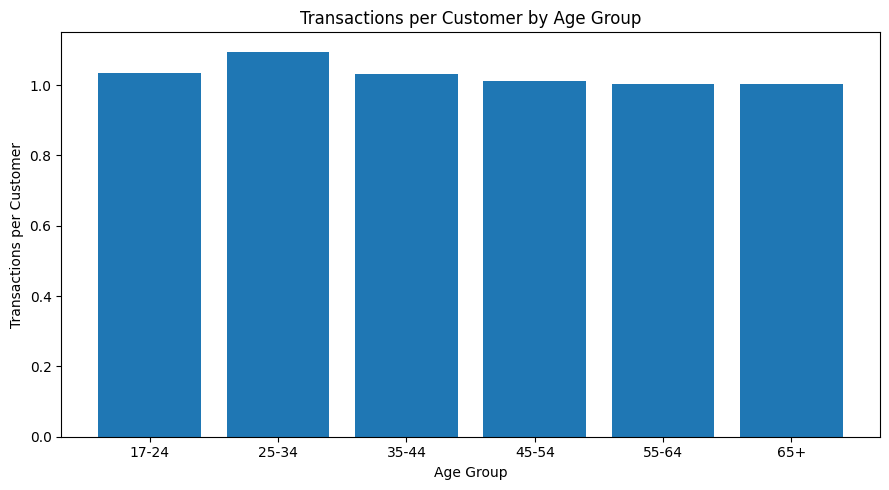

In [134]:
plt.figure(figsize=(9, 5))

plt.bar(
    age_summary.index,
    age_summary["TransactionsPerCustomer"]
)

plt.title("Transactions per Customer by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transactions per Customer")

plt.tight_layout()
plt.show()

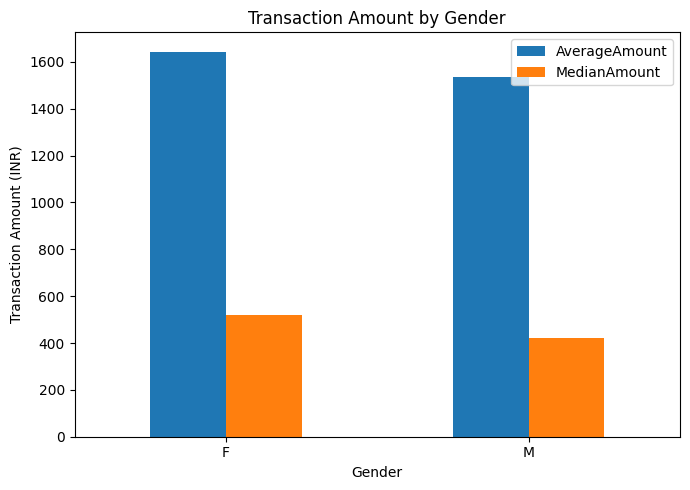

In [135]:
gender_amount = gender_summary[["AverageAmount", "MedianAmount"]]

gender_amount.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Transaction Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Transaction Amount (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [136]:
type_customer_ratio = (
    cust_summary["CustomerType"].value_counts(normalize=True) * 100
)

customer_value_compare = pd.DataFrame({
    "Customer Ratio (%)": type_customer_ratio,
    "Transaction Amount Ratio (%)": type_amount_ratio
})

In [137]:
customer_value_compare

,Customer Ratio (%),Transaction Amount Ratio (%)
CustomerType,,
Repeat,16.143709,29.129612
Single,83.856291,70.870388


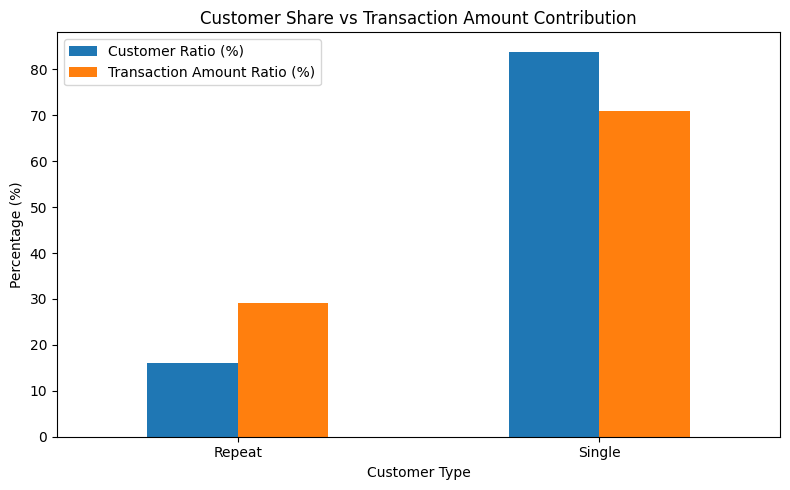

In [138]:
customer_value_compare.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Share vs Transaction Amount Contribution")
plt.xlabel("Customer Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Key Insights
### 1. 週末交易活動明顯高於平日
在完整交易期間 2016-08-01 至 2016-09-15 中，週末平均每日交易筆數約為 24,638 筆，較平日約 20,220 筆高出約 21.9%。此外，週末平均單筆交易金額亦較平日高約 7.6%，顯示週末總交易額的提升同時受到交易頻率與單筆交易金額增加影響，其中交易筆數的增幅更為明顯。

### 2. 25–34 歲客群交易活躍度最高
25–34 歲客群不僅具有最多的交易筆數，每位客戶平均交易次數亦為各年齡層最高，顯示其高交易量並非單純受到客戶人數較多影響，而是同時具有較高的交易活躍度。

65 歲以上客群雖具有最高的平均交易金額，但平均數明顯高於中位數，顯示平均值可能受到少數高額交易影響，因此不宜直接解讀為該客群普遍具有最高的交易金額。

### 3. 男女客戶呈現不同的交易特徵
男性客戶每位客戶平均交易次數略高於女性；另一方面，女性客戶的平均與中位交易金額皆高於男性，顯示女性客戶的單筆交易金額整體相對較高。

### 4. 重複交易客戶具有較高的交易價值
約 83.9% 的客戶在資料期間內僅有一筆交易，而重複交易客戶僅占約 16.1%。然而，重複交易客戶貢獻約 29.1% 的總交易金額，高於其客戶人數占比。

此外，重複交易客戶與單次交易客戶的平均單筆交易金額相近，但重複交易客戶的中位交易金額較高（₹662.20 vs ₹457.52），顯示典型的重複交易客戶具有相對較高的交易價值。

## 5. Business Recommendations
### 1. 強化週末交易時段的客戶經營與系統資源配置
由於週末交易筆數與平均交易金額皆高於平日，可將週末視為重要的交易活動時段。銀行可進一步分析週末使用的產品、通路與交易類型，作為行銷活動時機、服務資源及系統容量配置的參考。

### 2. 將 25–34 歲客群列為重要的活躍客群
25–34 歲客群具有較高的交易活躍度，可進一步結合產品持有、交易通路及消費類型等資料建立更完整的客戶輪廓，作為數位金融服務、產品推薦與交叉銷售策略的潛在目標客群。

### 3. 針對不同性別的交易特徵進一步分析需求差異
男性客戶交易頻率略高，而女性客戶的單筆交易金額相對較高。後續若能結合產品類型、交易用途及通路等資訊，可進一步判斷不同客群的需求差異，作為客群經營策略的參考。

### 4. 優先深化重複交易客戶的價值分析
重複交易客戶雖僅占約 16.1%，卻貢獻約 29.1% 的交易金額，顯示其具有較高的交易價值。可進一步分析重複交易客戶的產品使用、交易頻率及客戶特徵，識別具有較高價值潛力的客群，並設計提升持續交易與產品使用的經營策略。

## 6. Limitations
- 原始資料涵蓋的交易日期並不完整，因此時間趨勢分析僅採用日期連續完整的 2016-08-01 至 2016-09-15，避免後段缺漏日期影響趨勢判讀。
- 約 83.9% 的客戶在觀察期間內僅有一筆交易，因此資料不足以穩健衡量長期客戶忠誠度、留存或流失行為，本分析未直接套用傳統 RFM 模型。
- 原始出生日期存在缺失值、1800 年占位值及兩位數年份造成的世紀判讀問題，因此年齡分析僅使用經清理後可合理判讀的資料。
- 客戶所在地具有大量不同文字值及可能的地名格式差異，因此本次分析未將 Location 作為主要客群分群依據。
- 本資料僅包含交易、客戶基本屬性與帳戶餘額等有限資訊，缺乏產品類型、交易通路、行銷活動等變數，因此分析結果主要描述客戶交易行為的關聯性，不代表因果關係。